In [1]:
import pandas as pd
import glob
import numpy as np

In [2]:
di = 'silver/*.parquet'

In [3]:
files = glob.glob(di)

In [4]:
dfs = []
for file in files:
    df = pd.read_parquet(file)
    dfs.append(df)

In [5]:
df = pd.concat(dfs, ignore_index=True)

In [6]:
df.head()

,segment_id,timestamp_ist,lat,lon,speed_current_kmph,speed_freeflow_kmph,travel_time_sec,congestion_index,source,congestion_level
0,blr_mgroad,2025-10-28 10:52:34,12.9755,77.6041,18.0,25.0,1929,0.280,tomtom,0.280000
1,blr_silkboard,2025-10-28 10:52:34,12.9177,77.6233,44.0,44.0,46,0.000,tomtom,0.000000
2,blr_majestic,2025-10-28 10:52:34,12.9784,77.5720,16.0,25.0,604,0.360,tomtom,0.360000
3,blr_hebball,2025-10-28 10:52:34,13.0358,77.5970,32.0,46.0,581,0.304,tomtom,0.304348
4,blr_mgroad,2025-10-28 09:46:01,12.9755,77.6041,18.0,25.0,1929,0.280,tomtom,0.280000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   segment_id           1256 non-null   object 
 1   timestamp_ist        1256 non-null   object 
 2   lat                  1256 non-null   float64
 3   lon                  1256 non-null   float64
 4   speed_current_kmph   1256 non-null   float64
 5   speed_freeflow_kmph  1256 non-null   float64
 6   travel_time_sec      1256 non-null   int32  
 7   congestion_index     1256 non-null   float64
 8   source               1256 non-null   object 
 9   congestion_level     1256 non-null   float64
dtypes: float64(6), int32(1), object(3)
memory usage: 93.3+ KB


In [8]:
numerical_features = df.select_dtypes(include=[np.number])

In [9]:
numerical_features.corr()

,lat,lon,speed_current_kmph,speed_freeflow_kmph,travel_time_sec,congestion_index,congestion_level
lat,1.000000,-0.522699,-0.104131,0.099210,0.191321,0.314142,0.314217
lon,-0.522699,1.000000,0.571114,0.556625,-0.062097,-0.402784,-0.402797
speed_current_kmph,-0.104131,0.571114,1.000000,0.907655,-0.690559,-0.866643,-0.866607
speed_freeflow_kmph,0.099210,0.556625,0.907655,1.000000,-0.624878,-0.584891,-0.584815
travel_time_sec,0.191321,-0.062097,-0.690559,-0.624878,1.000000,0.667348,0.667281
congestion_index,0.314142,-0.402784,-0.866643,-0.584891,0.667348,1.000000,0.999999
congestion_level,0.314217,-0.402797,-0.866607,-0.584815,0.667281,0.999999,1.000000


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

<AxesSubplot:>

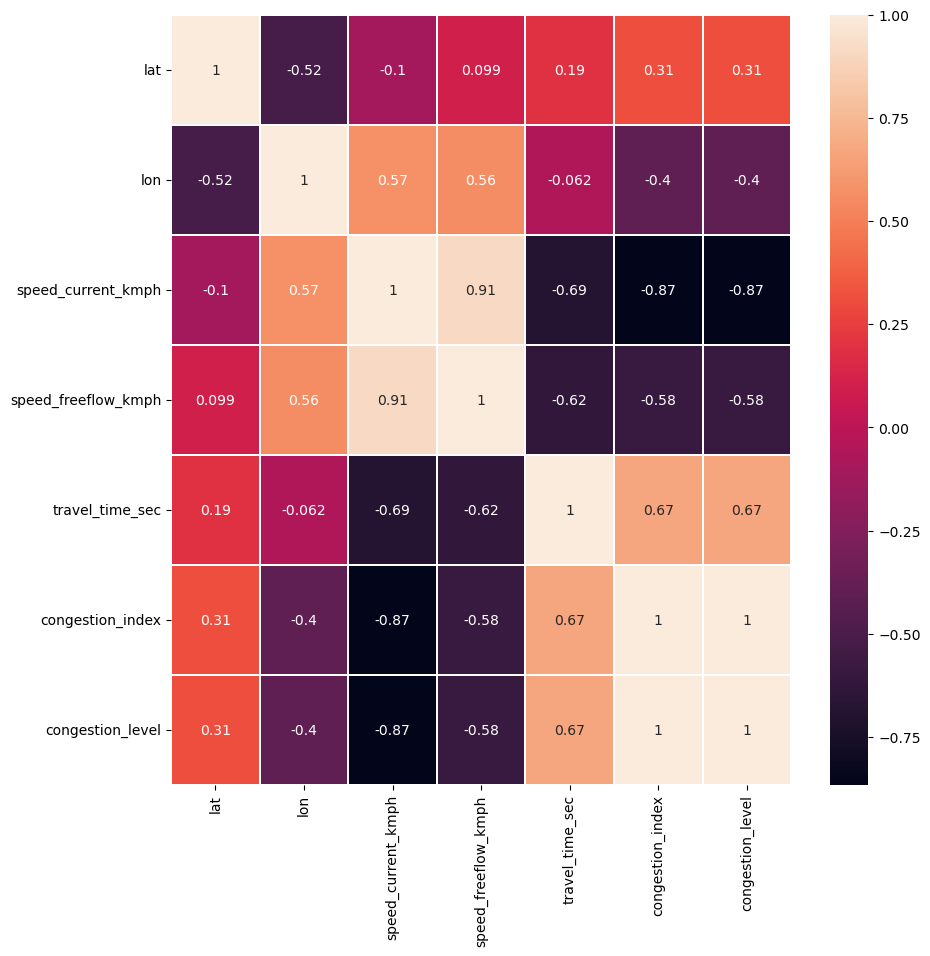

In [11]:
plt.figure(figsize=(10, 10))
sns.heatmap(numerical_features.corr(), annot=True, linewidths=0.2, cbar='coolwarm')

In [12]:
df = df[df['segment_id'] == 'blr_mgroad'].copy()

In [13]:
df.head()

,segment_id,timestamp_ist,lat,lon,speed_current_kmph,speed_freeflow_kmph,travel_time_sec,congestion_index,source,congestion_level
0,blr_mgroad,2025-10-28 10:52:34,12.9755,77.6041,18.0,25.0,1929,0.280,tomtom,0.280000
4,blr_mgroad,2025-10-28 09:46:01,12.9755,77.6041,18.0,25.0,1929,0.280,tomtom,0.280000
8,blr_mgroad,2025-10-28 10:36:03,12.9755,77.6041,17.0,26.0,2042,0.346,tomtom,0.346154
12,blr_mgroad,2025-10-28 11:34:24,12.9755,77.6041,16.0,26.0,2170,0.385,tomtom,0.384615
16,blr_mgroad,2025-10-28 10:00:55,12.9755,77.6041,16.0,26.0,2170,0.385,tomtom,0.384615


In [14]:
df.shape

(314, 10)

In [15]:
df = df.drop(columns=['source', 'congestion_level'], axis=1)

In [16]:
df.head()

,segment_id,timestamp_ist,lat,lon,speed_current_kmph,speed_freeflow_kmph,travel_time_sec,congestion_index
0,blr_mgroad,2025-10-28 10:52:34,12.9755,77.6041,18.0,25.0,1929,0.280
4,blr_mgroad,2025-10-28 09:46:01,12.9755,77.6041,18.0,25.0,1929,0.280
8,blr_mgroad,2025-10-28 10:36:03,12.9755,77.6041,17.0,26.0,2042,0.346
12,blr_mgroad,2025-10-28 11:34:24,12.9755,77.6041,16.0,26.0,2170,0.385
16,blr_mgroad,2025-10-28 10:00:55,12.9755,77.6041,16.0,26.0,2170,0.385


In [17]:
df.describe(include='all')

,segment_id,timestamp_ist,lat,lon,speed_current_kmph,speed_freeflow_kmph,travel_time_sec,congestion_index
count,314,314,3.140000e+02,3.140000e+02,314.000000,314.000000,314.000000,314.000000
unique,1,314,NaN,NaN,NaN,NaN,NaN,NaN
top,blr_mgroad,2025-10-28 10:52:34,NaN,NaN,NaN,NaN,NaN,NaN
freq,314,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.297550e+01,7.760410e+01,16.585987,25.875796,2101.191083,0.358955
std,NaN,NaN,8.895961e-15,2.419701e-13,1.030181,0.438397,130.844133,0.040128
min,NaN,NaN,1.297550e+01,7.760410e+01,14.000000,25.000000,1736.000000,0.231000
25%,NaN,NaN,1.297550e+01,7.760410e+01,16.000000,26.000000,2042.000000,0.346000
50%,NaN,NaN,1.297550e+01,7.760410e+01,17.000000,26.000000,2042.000000,0.346000
75%,NaN,NaN,1.297550e+01,7.760410e+01,17.000000,26.000000,2170.000000,0.385000


In [18]:
df['speed_ratio'] = df['speed_current_kmph'] / df['speed_freeflow_kmph']

In [19]:
df['timestamp_ist'] = pd.to_datetime(df['timestamp_ist'])

In [20]:
df['estimated_dist'] = (df['speed_freeflow_kmph'] * df['travel_time_sec']) / 3600

In [21]:
df['time_ratio'] = df['travel_time_sec'] / (df['estimated_dist'])

In [22]:
df['congestion_gap'] = df['speed_freeflow_kmph'] - df['speed_current_kmph']

In [23]:
df = df.drop(columns=['lat', 'lon'], axis=1)

In [24]:
df.head()

,segment_id,timestamp_ist,speed_current_kmph,speed_freeflow_kmph,travel_time_sec,congestion_index,speed_ratio,estimated_dist,time_ratio,congestion_gap
0,blr_mgroad,2025-10-28 10:52:34,18.0,25.0,1929,0.280,0.720000,13.395833,144.000000,7.0
4,blr_mgroad,2025-10-28 09:46:01,18.0,25.0,1929,0.280,0.720000,13.395833,144.000000,7.0
8,blr_mgroad,2025-10-28 10:36:03,17.0,26.0,2042,0.346,0.653846,14.747778,138.461538,9.0
12,blr_mgroad,2025-10-28 11:34:24,16.0,26.0,2170,0.385,0.615385,15.672222,138.461538,10.0
16,blr_mgroad,2025-10-28 10:00:55,16.0,26.0,2170,0.385,0.615385,15.672222,138.461538,10.0


<AxesSubplot:>

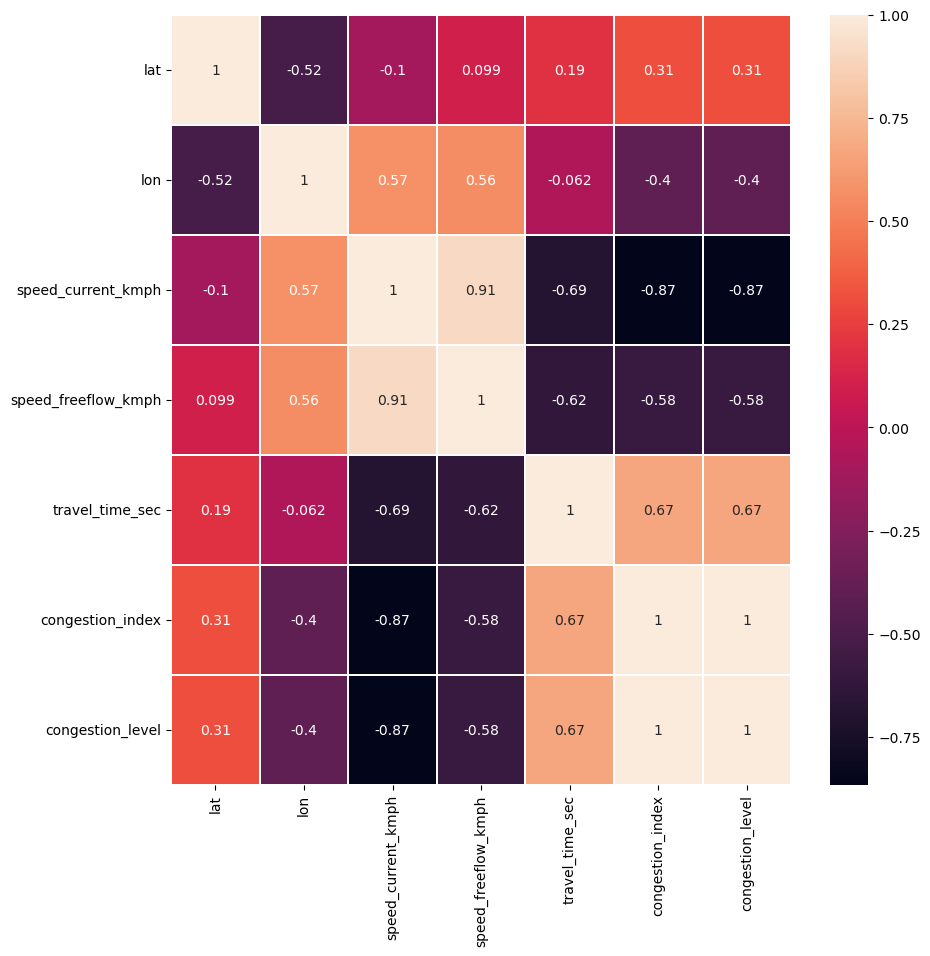

In [25]:
plt.figure(figsize=(10, 10))
sns.heatmap(numerical_features.corr(), annot=True, linewidths=0.2, cbar='coolwarm')

In [26]:
df.shape

(314, 10)

In [27]:
df['hour'] = df['timestamp_ist'].dt.hour
df['minute'] = df['timestamp_ist'].dt.minute
df['day_of_week'] = df['timestamp_ist'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_rush_hour'] = ((df['hour'].between(7, 10)) | (df['hour'].between(17, 20))).astype(int)

In [28]:
numerical_features = df.select_dtypes(include=[np.number])

In [29]:
df = df.drop(columns=['congestion_gap', 'estimated_dist'], axis=1)

Text(0.5, 1.0, 'Congestion Index')

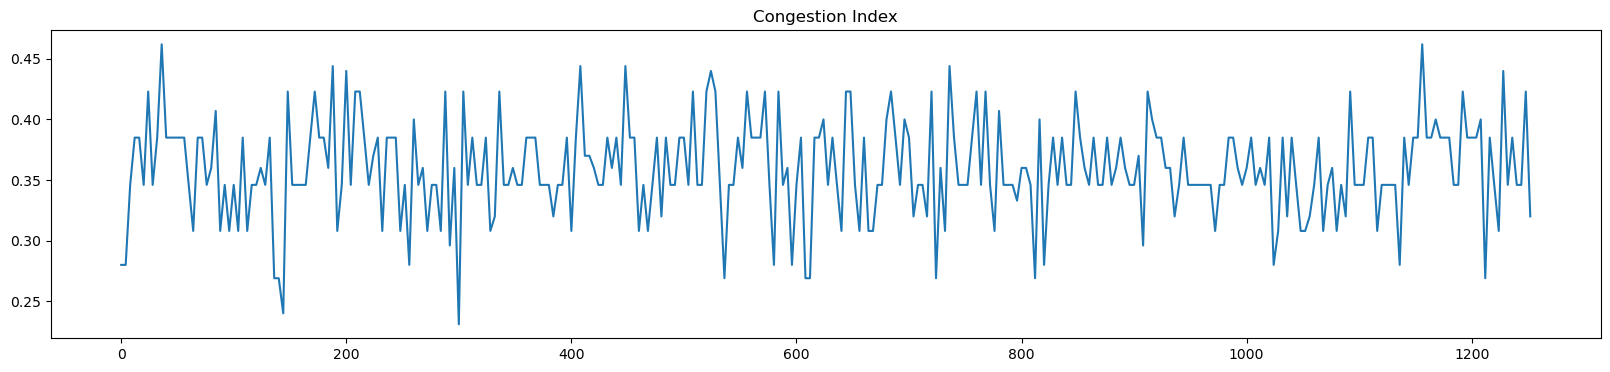

In [30]:
plt.figure(figsize=(20, 4))
plt.plot(df['congestion_index'])
plt.title('Congestion Index')

Text(0.5, 1.0, 'speed_current_kmph')

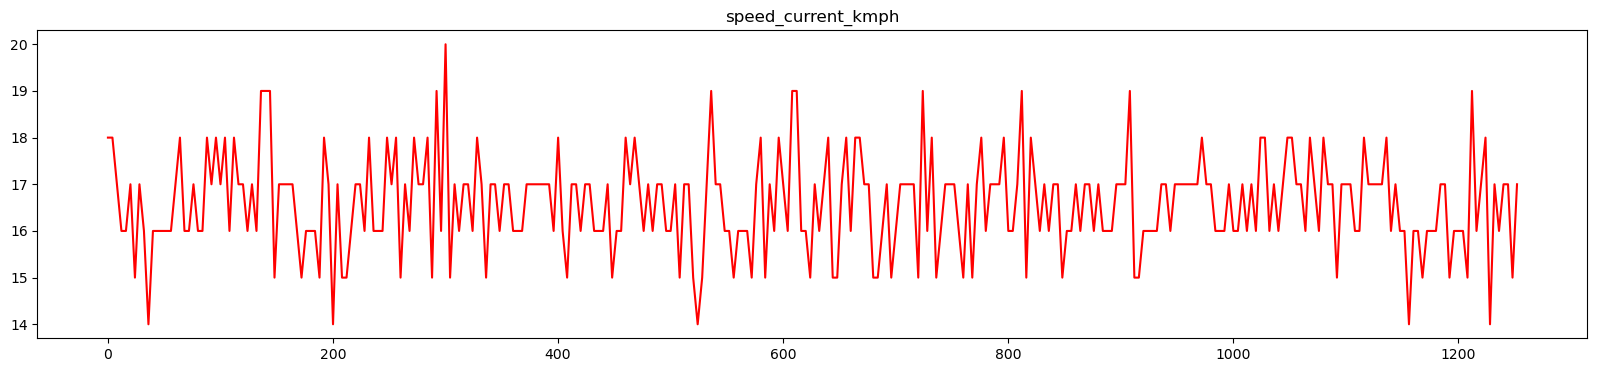

In [31]:
plt.figure(figsize=(20, 4))
plt.plot(df['speed_current_kmph'], color='red')
plt.title('speed_current_kmph')

Text(0.5, 1.0, 'speed_freeflow_kmph')

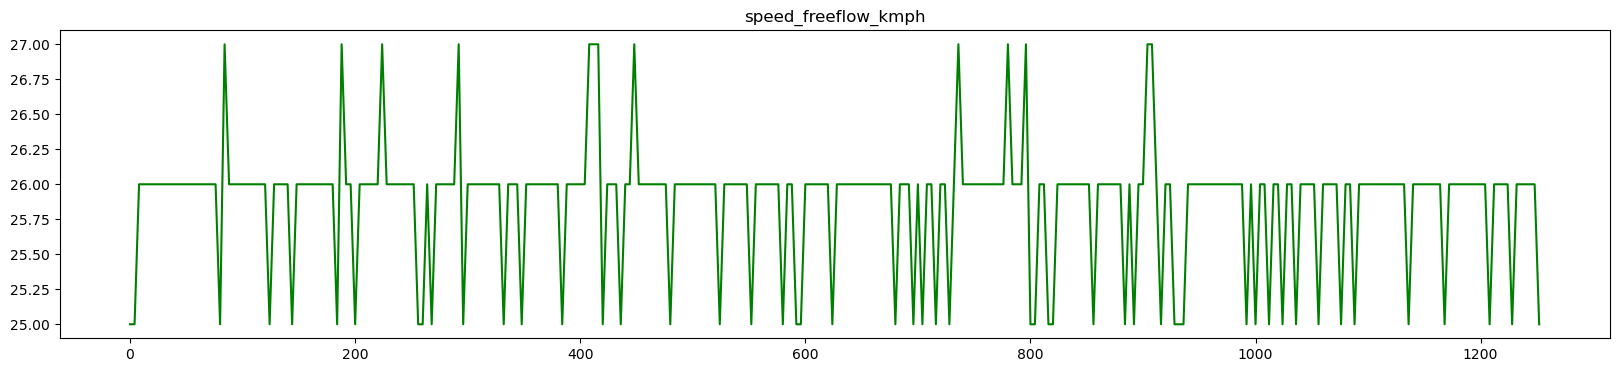

In [32]:
plt.figure(figsize=(20, 4))
plt.plot(df['speed_freeflow_kmph'], color='green')
plt.title('speed_freeflow_kmph')

Text(0.5, 1.0, 'speed_ratio')

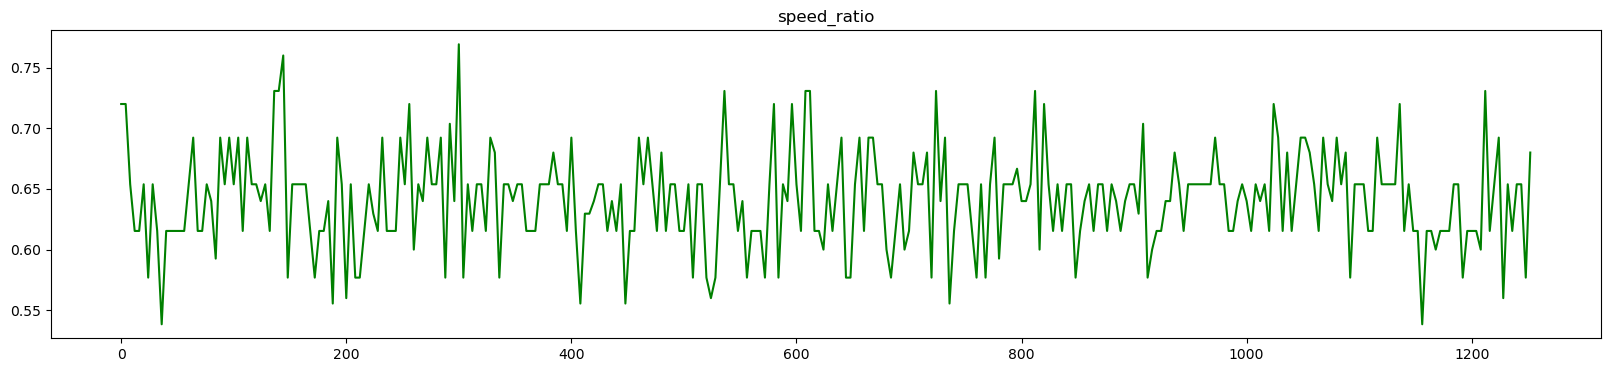

In [33]:
plt.figure(figsize=(20, 4))
plt.plot(df['speed_ratio'], color='green')
plt.title('speed_ratio')

In [34]:
df.isnull().sum()

segment_id             0
timestamp_ist          0
speed_current_kmph     0
speed_freeflow_kmph    0
travel_time_sec        0
congestion_index       0
speed_ratio            0
time_ratio             0
hour                   0
minute                 0
day_of_week            0
is_weekend             0
is_rush_hour           0
dtype: int64

In [35]:
df.isna().sum()

segment_id             0
timestamp_ist          0
speed_current_kmph     0
speed_freeflow_kmph    0
travel_time_sec        0
congestion_index       0
speed_ratio            0
time_ratio             0
hour                   0
minute                 0
day_of_week            0
is_weekend             0
is_rush_hour           0
dtype: int64

In [36]:
# Ensure time is sorted
df = df.sort_values('timestamp_ist').reset_index(drop=True)

# Define rolling window size (e.g., 5 observations)
window = 5

# Rolling features for speed_current_kmph
df['roll_mean_speed'] = df['speed_current_kmph'].rolling(window).mean()
df['roll_std_speed']  = df['speed_current_kmph'].rolling(window).std()
df['roll_min_speed']  = df['speed_current_kmph'].rolling(window).min()
df['roll_max_speed']  = df['speed_current_kmph'].rolling(window).max()
df['roll_median_speed'] = df['speed_current_kmph'].rolling(window).median()
df['roll_diff_speed'] = df['speed_current_kmph'].diff()

# Optional: Rolling features for freeflow speed (if present)
if 'speed_freeflow_kmph' in df.columns:
    df['roll_mean_freeflow'] = df['speed_freeflow_kmph'].rolling(window).mean()
    df['roll_std_freeflow']  = df['speed_freeflow_kmph'].rolling(window).std()
    df['roll_diff_freeflow'] = df['speed_freeflow_kmph'].diff()

# Fill initial NaNs caused by rolling window
df.fillna(method='bfill', inplace=True)

# Display the new columns
df.head()

,segment_id,timestamp_ist,speed_current_kmph,speed_freeflow_kmph,travel_time_sec,congestion_index,speed_ratio,time_ratio,hour,minute,...,is_rush_hour,roll_mean_speed,roll_std_speed,roll_min_speed,roll_max_speed,roll_median_speed,roll_diff_speed,roll_mean_freeflow,roll_std_freeflow,roll_diff_freeflow
0,blr_mgroad,2025-10-28 09:31:08,15.0,26.0,2314,0.423,0.576923,138.461538,9,31,...,1,15.6,0.547723,15.0,16.0,16.0,0.0,26.4,0.547723,1.0
1,blr_mgroad,2025-10-28 09:31:39,15.0,27.0,2314,0.444,0.555556,133.333333,9,31,...,1,15.6,0.547723,15.0,16.0,16.0,0.0,26.4,0.547723,1.0
2,blr_mgroad,2025-10-28 09:32:09,16.0,26.0,2170,0.385,0.615385,138.461538,9,32,...,1,15.6,0.547723,15.0,16.0,16.0,1.0,26.4,0.547723,-1.0
3,blr_mgroad,2025-10-28 09:32:40,16.0,26.0,2170,0.385,0.615385,138.461538,9,32,...,1,15.6,0.547723,15.0,16.0,16.0,0.0,26.4,0.547723,0.0
4,blr_mgroad,2025-10-28 09:33:11,16.0,27.0,2170,0.407,0.592593,133.333333,9,33,...,1,15.6,0.547723,15.0,16.0,16.0,0.0,26.4,0.547723,1.0


In [37]:
num = df.select_dtypes(include=[np.number])

<AxesSubplot:>

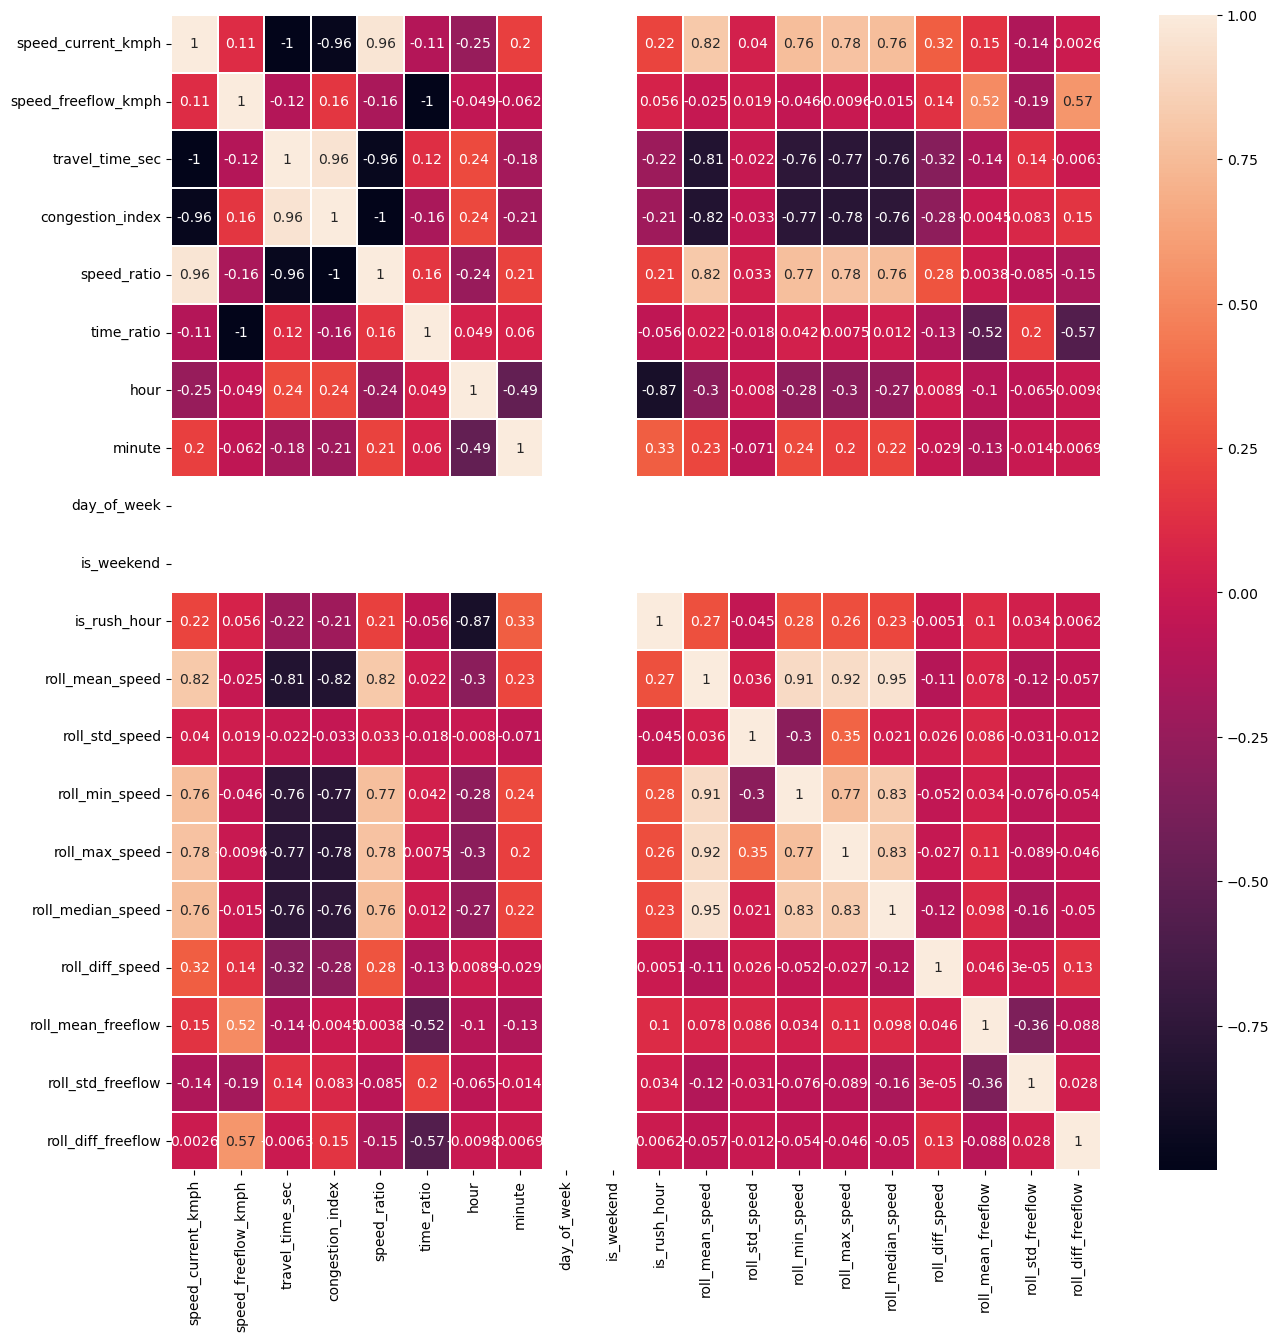

In [38]:
plt.figure(figsize=(15, 15))
sns.heatmap(num.corr(), annot=True, linewidths=0.2, cbar='coolwarm')

In [39]:
df = df.drop(columns=['roll_min_speed', 'roll_max_speed', 'roll_median_speed'], axis=1)

In [40]:
df.shape

(314, 19)

In [86]:
df = df.sort_values('timestamp_ist').reset_index(drop=True)

# Define features (X) and target (y)
X = df.drop(['congestion_index','segment_id', 'timestamp_ist'], axis=1)
y = df['congestion_index']

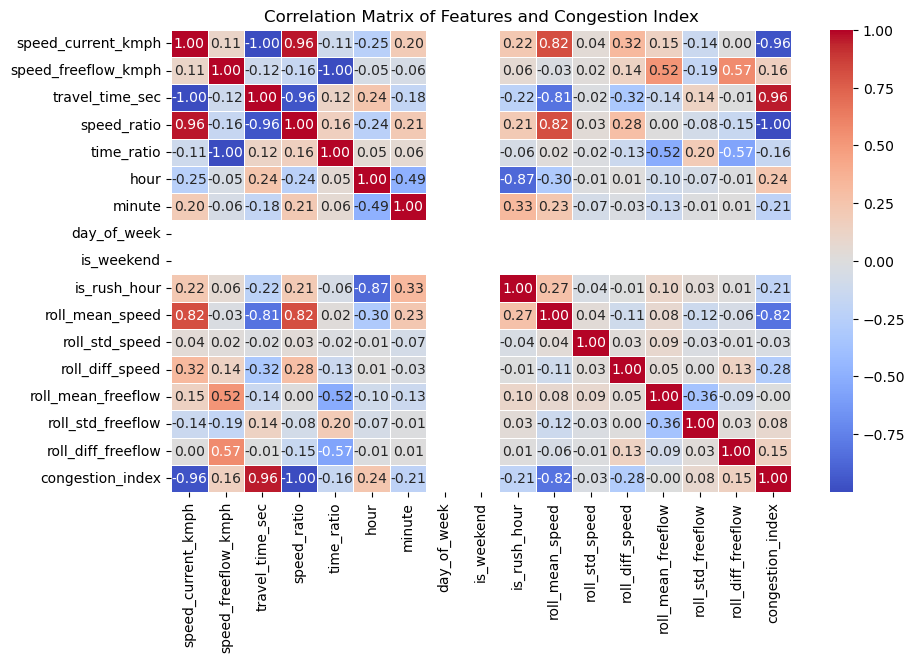

In [87]:
# ✅ Concatenate X and y
df_corr = pd.concat([X, y], axis=1)

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Features and Congestion Index")
plt.show()

In [78]:

# 80% train, 20% test split chronologically
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train duration:", df['timestamp_ist'].iloc[0], "→", df['timestamp_ist'].iloc[split_index-1])
print("Test duration:", df['timestamp_ist'].iloc[split_index], "→", df['timestamp_ist'].iloc[-1])

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.fit_transform(X_test)
y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test = scaler_y.fit_transform(y_test.values.reshape(-1, 1)).flatten()

Train shape: (251, 16)
Test shape: (63, 16)
Train duration: 2025-10-28 09:31:08 → 2025-10-28 11:46:43
Test duration: 2025-10-28 11:47:14 → 2025-10-28 12:19:06


In [79]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   speed_current_kmph   251 non-null    float64
 1   speed_freeflow_kmph  251 non-null    float64
 2   travel_time_sec      251 non-null    int32  
 3   speed_ratio          251 non-null    float64
 4   time_ratio           251 non-null    float64
 5   hour                 251 non-null    int32  
 6   minute               251 non-null    int32  
 7   day_of_week          251 non-null    int32  
 8   is_weekend           251 non-null    int32  
 9   is_rush_hour         251 non-null    int32  
 10  roll_mean_speed      251 non-null    float64
 11  roll_std_speed       251 non-null    float64
 12  roll_diff_speed      251 non-null    float64
 13  roll_mean_freeflow   251 non-null    float64
 14  roll_std_freeflow    251 non-null    float64
 15  roll_diff_freeflow   251 non-null    flo

In [80]:
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

X_train_reshaped.shape
X_test_reshaped.shape

(63, 1, 16)

def create_sequences(X, y, time_steps=30):
    """
    Convert time series data into sequences for LSTM/GRU models.
    X : DataFrame or numpy array of features
    y : target series (e.g., congestion_index)
    time_steps : number of past steps to use as input
    """
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:(i + time_steps)].values)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 10  # You can experiment: 5, 10, 15 minutes etc.

X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIME_STEPS)
X_test_seq, y_test_seq   = create_sequences(X_test, y_test, TIME_STEPS)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq

In [81]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(128, input_shape=(X_train_reshaped.shape[1:]), return_sequences=False),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping to prevent overfitting
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_test_reshaped, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[es],
    verbose=1
)


Epoch 1/100
8/8 [==============================] - 5s 150ms/step - loss: 0.2210 - mae: 0.4297 - val_loss: 0.0816 - val_mae: 0.2226
Epoch 2/100
8/8 [==============================] - 0s 14ms/step - loss: 0.0604 - mae: 0.2001 - val_loss: 0.1179 - val_mae: 0.2919
Epoch 3/100
8/8 [==============================] - 0s 12ms/step - loss: 0.0521 - mae: 0.1792 - val_loss: 0.1230 - val_mae: 0.2992
Epoch 4/100
8/8 [==============================] - 0s 16ms/step - loss: 0.0360 - mae: 0.1490 - val_loss: 0.0715 - val_mae: 0.2248
Epoch 5/100
8/8 [==============================] - 0s 18ms/step - loss: 0.0309 - mae: 0.1394 - val_loss: 0.0604 - val_mae: 0.2064
Epoch 6/100
8/8 [==============================] - 0s 17ms/step - loss: 0.0270 - mae: 0.1300 - val_loss: 0.0684 - val_mae: 0.2230
Epoch 7/100
8/8 [==============================] - 0s 19ms/step - loss: 0.0198 - mae: 0.1102 - val_loss: 0.0593 - val_mae: 0.2085
Epoch 8/100
8/8 [==============================] - 0s 15ms/step - loss: 0.0172 - mae: 0.1

Epoch 63/100
8/8 [==============================] - 0s 15ms/step - loss: 8.1189e-04 - mae: 0.0213 - val_loss: 7.3397e-04 - val_mae: 0.0215
Epoch 64/100
8/8 [==============================] - 0s 18ms/step - loss: 7.7943e-04 - mae: 0.0227 - val_loss: 9.2652e-04 - val_mae: 0.0236
Epoch 65/100
8/8 [==============================] - 0s 18ms/step - loss: 7.6355e-04 - mae: 0.0218 - val_loss: 0.0011 - val_mae: 0.0264
Epoch 66/100
8/8 [==============================] - 0s 16ms/step - loss: 7.9375e-04 - mae: 0.0220 - val_loss: 7.4642e-04 - val_mae: 0.0205
Epoch 67/100
8/8 [==============================] - 0s 16ms/step - loss: 6.5000e-04 - mae: 0.0208 - val_loss: 9.9243e-04 - val_mae: 0.0246
Epoch 68/100
8/8 [==============================] - 0s 15ms/step - loss: 7.6256e-04 - mae: 0.0220 - val_loss: 9.4144e-04 - val_mae: 0.0236
Epoch 69/100
8/8 [==============================] - 0s 17ms/step - loss: 6.7334e-04 - mae: 0.0201 - val_loss: 7.9737e-04 - val_mae: 0.0209
Epoch 70/100
8/8 [=============

In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test_reshaped)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")


2/2 [==============================] - 1s 11ms/step
MAE: 0.0176, RMSE: 0.0243



Training LSTM model...
Epoch 1/200
29/29 [==============================] - 5s 37ms/step - loss: 0.2906 - val_loss: 0.5026
Epoch 2/200
29/29 [==============================] - 0s 5ms/step - loss: 0.2475 - val_loss: 0.4439
Epoch 3/200
29/29 [==============================] - 0s 6ms/step - loss: 0.2030 - val_loss: 0.3788
Epoch 4/200
29/29 [==============================] - 0s 5ms/step - loss: 0.1562 - val_loss: 0.3059
Epoch 5/200
29/29 [==============================] - 0s 5ms/step - loss: 0.1099 - val_loss: 0.2303
Epoch 6/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0715 - val_loss: 0.1641
Epoch 7/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0484 - val_loss: 0.1194
Epoch 8/200
29/29 [==============================] - 0s 6ms/step - loss: 0.0409 - val_loss: 0.0966
Epoch 9/200
29/29 [==============================] - 0s 6ms/step - loss: 0.0385 - val_loss: 0.0865
Epoch 10/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0355 - v

29/29 [==============================] - 0s 6ms/step - loss: 0.0022 - val_loss: 9.3376e-04
Epoch 83/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0023 - val_loss: 0.0010
Epoch 84/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0022 - val_loss: 8.9655e-04
Epoch 85/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0022 - val_loss: 9.0739e-04
Epoch 86/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0023 - val_loss: 8.9971e-04
Epoch 87/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0021 - val_loss: 9.0988e-04
Epoch 88/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0019 - val_loss: 9.3072e-04
Epoch 89/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0023 - val_loss: 9.6511e-04
Epoch 90/200
29/29 [==============================] - 0s 6ms/step - loss: 0.0021 - val_loss: 9.1686e-04
Epoch 91/200
29/29 [==============================] - 0s 6ms/step - loss: 0.0021 

29/29 [==============================] - 0s 3ms/step - loss: 0.0029 - val_loss: 0.0078
Epoch 61/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0028 - val_loss: 0.0073
Epoch 62/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0026 - val_loss: 0.0068
Epoch 63/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0025 - val_loss: 0.0064
Epoch 64/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0024 - val_loss: 0.0060
Epoch 65/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0023 - val_loss: 0.0056
Epoch 66/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0022 - val_loss: 0.0052
Epoch 67/200
29/29 [==============================] - 0s 3ms/step - loss: 0.0021 - val_loss: 0.0049
Epoch 68/200
29/29 [==============================] - 0s 3ms/step - loss: 0.0020 - val_loss: 0.0046
Epoch 69/200
29/29 [==============================] - 0s 3ms/step - loss: 0.0019 - val_loss: 0.0043
Epoch 70/200


29/29 [==============================] - 0s 4ms/step - loss: 2.8669e-04 - val_loss: 4.7423e-04
Epoch 138/200
29/29 [==============================] - 0s 3ms/step - loss: 2.8016e-04 - val_loss: 4.7155e-04
Epoch 139/200
29/29 [==============================] - 0s 4ms/step - loss: 2.7378e-04 - val_loss: 4.6871e-04
Epoch 140/200
29/29 [==============================] - 0s 4ms/step - loss: 2.6754e-04 - val_loss: 4.6573e-04
Epoch 141/200
29/29 [==============================] - 0s 4ms/step - loss: 2.6143e-04 - val_loss: 4.6260e-04
Epoch 142/200
29/29 [==============================] - 0s 4ms/step - loss: 2.5546e-04 - val_loss: 4.5933e-04
Epoch 143/200
29/29 [==============================] - 0s 4ms/step - loss: 2.4962e-04 - val_loss: 4.5592e-04
Epoch 144/200
29/29 [==============================] - 0s 4ms/step - loss: 2.4390e-04 - val_loss: 4.5238e-04
Epoch 145/200
29/29 [==============================] - 0s 4ms/step - loss: 2.3831e-04 - val_loss: 4.4871e-04
Epoch 146/200
29/29 [============

29/29 [==============================] - 0s 4ms/step - loss: 0.0347 - val_loss: 0.0820
Epoch 13/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0338 - val_loss: 0.0782
Epoch 14/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0330 - val_loss: 0.0755
Epoch 15/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0323 - val_loss: 0.0733
Epoch 16/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0315 - val_loss: 0.0714
Epoch 17/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0307 - val_loss: 0.0696
Epoch 18/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0300 - val_loss: 0.0679
Epoch 19/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0292 - val_loss: 0.0662
Epoch 20/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0284 - val_loss: 0.0646
Epoch 21/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0277 - val_loss: 0.0629
Epoch 22/200


29/29 [==============================] - 0s 5ms/step - loss: 9.3122e-04 - val_loss: 5.1638e-04
Epoch 94/200
29/29 [==============================] - 0s 5ms/step - loss: 9.0544e-04 - val_loss: 4.8772e-04
Epoch 95/200
29/29 [==============================] - 0s 5ms/step - loss: 8.8075e-04 - val_loss: 4.6373e-04
Epoch 96/200
29/29 [==============================] - 0s 5ms/step - loss: 8.5709e-04 - val_loss: 4.4395e-04
Epoch 97/200
29/29 [==============================] - 0s 5ms/step - loss: 8.3439e-04 - val_loss: 4.2799e-04
Epoch 98/200
29/29 [==============================] - 0s 5ms/step - loss: 8.1259e-04 - val_loss: 4.1546e-04
Epoch 99/200
29/29 [==============================] - 0s 5ms/step - loss: 7.9163e-04 - val_loss: 4.0599e-04
Epoch 100/200
29/29 [==============================] - 0s 5ms/step - loss: 7.7148e-04 - val_loss: 3.9927e-04
Epoch 101/200
29/29 [==============================] - 0s 4ms/step - loss: 7.5207e-04 - val_loss: 3.9498e-04
Epoch 102/200
29/29 [==================

29/29 [==============================] - 0s 5ms/step - loss: 0.0031 - val_loss: 0.0072
Epoch 60/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0030 - val_loss: 0.0067
Epoch 61/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0028 - val_loss: 0.0062
Epoch 62/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0027 - val_loss: 0.0057
Epoch 63/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0026 - val_loss: 0.0053
Epoch 64/200
29/29 [==============================] - 0s 4ms/step - loss: 0.0025 - val_loss: 0.0049
Epoch 65/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0024 - val_loss: 0.0045
Epoch 66/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0023 - val_loss: 0.0042
Epoch 67/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0022 - val_loss: 0.0039
Epoch 68/200
29/29 [==============================] - 0s 5ms/step - loss: 0.0022 - val_loss: 0.0036
Epoch 69/200


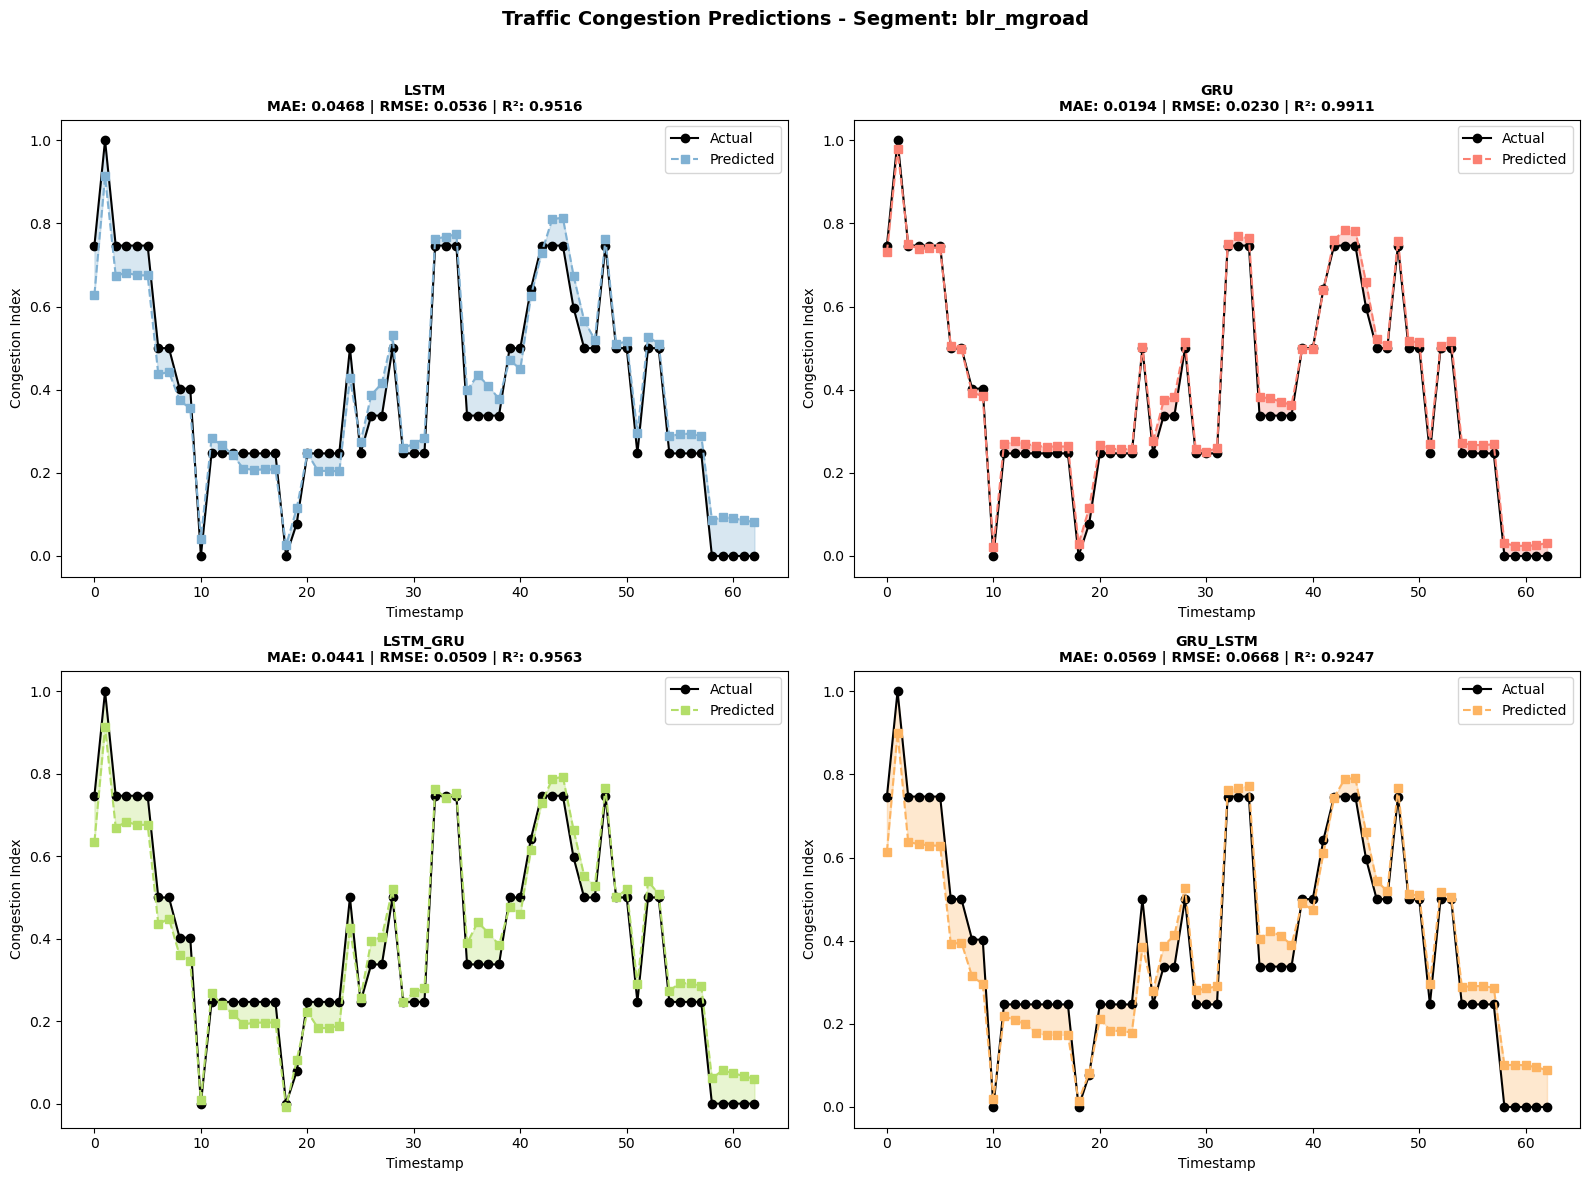

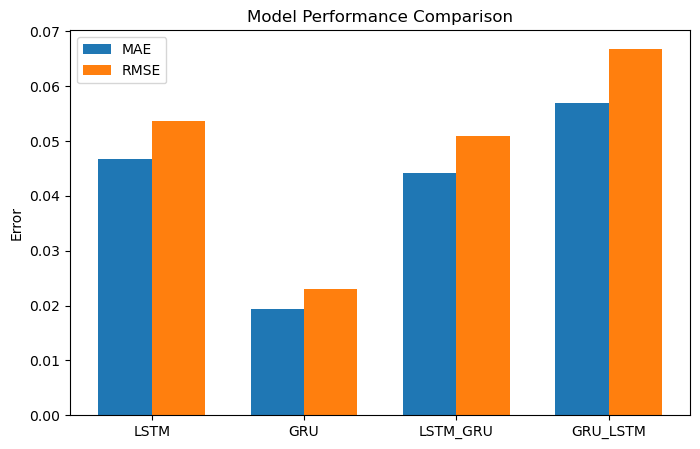

In [88]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

# --- Prevent TensorFlow warnings ---
import warnings
warnings.filterwarnings('ignore')

# --- Early stopping ---
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# --- Model builders ---
def build_lstm(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(64),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-4), loss='mse')
    return model

def build_gru(input_shape):
    model = Sequential([
        GRU(64, activation='tanh', input_shape=input_shape),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-4), loss='mse')
    return model

def build_lstm_gru(input_shape):
    model = Sequential([
        LSTM(64, activation='tanh', return_sequences=True, input_shape=input_shape),
        GRU(32, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-4), loss='mse')
    return model

def build_gru_lstm(input_shape):
    model = Sequential([
        GRU(64, activation='tanh', return_sequences=True, input_shape=input_shape),
        LSTM(32),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-4), loss='mse')
    return model

# --- Models dictionary ---
models = {
    "LSTM": build_lstm(X_train_reshaped.shape[1:]),
    "GRU": build_gru(X_train_reshaped.shape[1:]),
    "LSTM_GRU": build_lstm_gru(X_train_reshaped.shape[1:]),
    "GRU_LSTM": build_gru_lstm(X_train_reshaped.shape[1:])
}

results = {}

# --- Train and evaluate ---
for name, model in models.items():
    print(f"\nTraining {name} model...")
    model.fit(
        X_train_reshaped, y_train,
        validation_split=0.1,
        epochs=200,
        batch_size=8,
        verbose=1,
        shuffle=False,
        callbacks=[early_stop]
    )

    y_pred = model.predict(X_test_reshaped)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {"mae": mae, "rmse": rmse, "r2": r2, "y_pred": y_pred.flatten()}
    print(f"{name} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# --- Visualization like your uploaded figure ---
plt.figure(figsize=(16, 12))
plt.suptitle(f"Traffic Congestion Predictions - Segment: blr_mgroad", fontsize=14, fontweight='bold')

colors = {
    "LSTM": "#80b1d3",
    "GRU": "#fb8072",
    "LSTM_GRU": "#b3de69",
    "GRU_LSTM": "#fdb462"
}

for i, (name, res) in enumerate(results.items(), 1):
    plt.subplot(2, 2, i)
    plt.plot(y_test, color='black', label='Actual', linewidth=1.5, marker='o')
    plt.plot(res["y_pred"], color=colors[name], linestyle='--', label='Predicted', marker='s')
    plt.fill_between(range(len(y_test)), y_test, res["y_pred"], color=colors[name], alpha=0.3)
    plt.title(f"{name}\nMAE: {res['mae']:.4f} | RMSE: {res['rmse']:.4f} | R²: {res['r2']:.4f}",
              fontsize=10, fontweight='bold')
    plt.xlabel("Timestamp")
    plt.ylabel("Congestion Index")
    plt.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --- Bar Chart Summary ---
plt.figure(figsize=(8, 5))
names = list(results.keys())
mae_vals = [results[n]["mae"] for n in names]
rmse_vals = [results[n]["rmse"] for n in names]
x = np.arange(len(names))
width = 0.35
plt.bar(x - width/2, mae_vals, width, label='MAE')
plt.bar(x + width/2, rmse_vals, width, label='RMSE')
plt.xticks(x, names)
plt.ylabel("Error")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()
